In [20]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd


In [23]:
class LungCancerDataset(Dataset):
    def __init__(self, image_dir, transform=None, metric_learning=False):
        self.image_dir = image_dir
        self.transform = transform
        self.metric_learning = metric_learning
        
        # Create a class map
        self.class_map = {folder_name: idx for idx, folder_name in enumerate(os.listdir(image_dir)) if os.path.isdir(os.path.join(image_dir, folder_name))}

        self.image_paths = []
        self.labels = []
        self.class_to_images = {label: [] for label in self.class_map.values()}

        for class_name, label in self.class_map.items():
            class_dir = os.path.join(image_dir, class_name)
            for file_name in os.listdir(class_dir):
                if file_name.endswith('.png') or file_name.endswith('.jpg') or file_name.endswith('.jpeg'):
                    img_path = os.path.join(class_dir, file_name)
                    self.image_paths.append(img_path)
                    self.labels.append(label)
                    self.class_to_images[label].append(img_path)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        
        if not self.metric_learning:
            return image, label
        else:
            # Prepare a triplet (anchor, positive, negative) for metric learning
            # Anchor
            anchor_image = image
            anchor_label = label

            # Positive: Randomly select another image of the same class
            positive_image_path = random.choice(self.class_to_images[anchor_label])
            positive_image = Image.open(positive_image_path).convert("RGB")
            if self.transform:
                positive_image = self.transform(positive_image)

            # Negative: Randomly select an image from a different class
            negative_label = random.choice([l for l in self.class_to_images.keys() if l != anchor_label])
            negative_image_path = random.choice(self.class_to_images[negative_label])
            negative_image = Image.open(negative_image_path).convert("RGB")
            if self.transform:
                negative_image = self.transform(negative_image)

            return anchor_image, positive_image, negative_image


In [24]:
def get_dataloader(image_dir, batch_size=32, shuffle=True, metric_learning=False):
    image_transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust size if needed
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create an instance of the LungCancerDataset
    dataset = LungCancerDataset(image_dir=image_dir, transform=image_transform, metric_learning=metric_learning)
    
    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=4)

    return dataloader, dataset


In [25]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.activations = {}
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # Output: [batch, 32, 224, 224]
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Output: [batch, 64, 112, 112]
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # Output: [batch, 128, 56, 56]
        
        self.pool = nn.MaxPool2d(2, 2)
        
        flattened_size = 128 * 28 * 28  # For images resized to 224x224
        
        self.fc1 = nn.Linear(flattened_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
        # Register hooks
        self.conv1.register_forward_hook(self.save_activation('conv1'))
        self.conv2.register_forward_hook(self.save_activation('conv2'))
        self.conv3.register_forward_hook(self.save_activation('conv3'))
        self.fc1.register_forward_hook(self.save_activation('fc1'))

    def save_activation(self, name):
        def hook(module, input, output):
            self.activations[name] = output.detach()
        return hook

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))  # Output: [batch, 32, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # Output: [batch, 64, 56, 56]
        x = self.pool(F.relu(self.conv3(x)))  # Output: [batch, 128, 28, 28]
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        embedding = F.relu(self.fc2(x))
        x = self.fc3(embedding)
    
        if return_embedding:
            return embedding
        else:
            return x


In [26]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using CUDA device.")
elif torch.backends.mps.is_available():
    device = torch.device('mps')  # For M1 Macs 
    print("Using MPS device.")
else:
    device = torch.device('cpu')
    print("Using CPU.")


Using CUDA device.


In [95]:
# Set data path and batch size
data_path = "Data/Image/IQ-OTHNCCD"
batch_size = 16  # Adjust based on your GPU memory

# Get dataloaders and dataset
dataloader_metric, dataset = get_dataloader(data_path, batch_size=batch_size, shuffle=True, metric_learning=True)
#dataloader, dataset = get_dataloader(data_path, batch_size=batch_size, shuffle=True, metric_learning=False)

# Get the number of classes from the dataset
num_classes = len(dataset.class_map)


In [96]:
model = SimpleCNN(num_classes=num_classes).to(device)


In [97]:
def train_network(network, dataloader, device, num_epochs=10, learning_rate=0.001, use_metric_learning=False):
    # Criterion for cross-entropy loss
    criterion = nn.CrossEntropyLoss()
    
    # Criterion for metric learning (e.g., TripletMarginLoss)
    metric_criterion = nn.TripletMarginLoss(margin=1.0, p=2)
    
    optimizer = optim.Adam(network.parameters(), lr=learning_rate)
    
    for epoch in range(num_epochs):
        network.train()
        running_loss = 0.0
        for data in dataloader:
            if use_metric_learning:
                anchor, positive, negative = data
                anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
                
                optimizer.zero_grad()
                
                anchor_out = network(anchor, return_embedding=True)
                positive_out = network(positive, return_embedding=True)
                negative_out = network(negative, return_embedding=True)
                
                loss = metric_criterion(anchor_out, positive_out, negative_out)
            else:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                
                optimizer.zero_grad()
                
                outputs = network(images)
                
                loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(dataloader)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}')
    
    print('Training completed.')


In [98]:
# Train with metric learning
train_network(model, dataloader_metric, device, num_epochs=5, use_metric_learning=True)

# Save the model
torch.save(model.state_dict(), 'model_metric.pth')

# Train with standard classification loss
#train_network(model, dataloader, device, num_epochs=5, use_metric_learning=False)

# Save the model
#torch.save(model.state_dict(), 'model_classification.pth')


Epoch [1/5], Loss: 0.5411
Epoch [2/5], Loss: 0.2196
Epoch [3/5], Loss: 0.1191
Epoch [4/5], Loss: 0.0569
Epoch [5/5], Loss: 0.0847
Training completed.


In [99]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from causallearn.search.ConstraintBased.PC import pc
import networkx as nx
import matplotlib.pyplot as plt

# ---- Step 1: Extract Activations ---- #
def extract_activations(model, dataloader, device):
    model.eval()
    activations = {layer: [] for layer in model.activations.keys()}
    labels = []

    with torch.no_grad():
        for images, batch_labels in dataloader:
            images = images.to(device)
            labels.extend(batch_labels.cpu().numpy())
            
            # Forward pass
            _ = model(images)
            
            # Store activations
            
            for layer, activation in model.activations.items():
                if activation.dim() == 4:  # Convolutional layers
                    pooled_activation = F.adaptive_avg_pool2d(activation, output_size=(1, 1))
                    activations[layer].append(pooled_activation.view(pooled_activation.size(0), -1).cpu())
                elif activation.dim() == 2:  # Fully connected layers
                    activations[layer].append(activation.cpu())
                else:
                    raise ValueError(f"Unexpected activation shape: {activation.shape}")
    
    # Concatenate and return
    activations = {layer: torch.cat(act, dim=0).numpy() for layer, act in activations.items()}
    return activations, np.array(labels)


# ---- Step 2: Perform Clustering with Optimization ---- #
def perform_clustering_optimized(activations, max_clusters=10):
    clustering_results = {}
    for layer, activations_layer in activations.items():
        # Normalize activations
        scaler = StandardScaler()
        normalized_activations = scaler.fit_transform(activations_layer)
        
        # Reduce dimensionality
        pca = PCA(n_components=50)
        reduced_activations = pca.fit_transform(normalized_activations)
        
        # Find optimal clusters
        scores = []
        for n_clusters in range(2, max_clusters + 1):
            kmeans = KMeans(n_clusters=n_clusters, random_state=42)
            clusters = kmeans.fit_predict(reduced_activations)
            score = silhouette_score(reduced_activations, clusters)
            scores.append((n_clusters, score))
        
        # Select the number of clusters with the highest silhouette score
        best_n_clusters = max(scores, key=lambda x: x[1])[0]
        print(f"Optimal clusters for layer {layer}: {best_n_clusters}")
        
        # Perform final clustering
        kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
        clustering_results[layer] = kmeans.fit_predict(reduced_activations)
    
    return clustering_results


# ---- Step 3: Generate Latent Cluster Dataset ---- #
def create_latent_cluster_dataset(clustering_results, labels):
    cluster_data = {f"{layer}_cluster": clusters for layer, clusters in clustering_results.items()}
    cluster_data['label'] = labels
    return pd.DataFrame(cluster_data)

# ---- Step 4: Perform Causal Discovery for All Layers ---- #
def causal_discovery_all_layers(cluster_df, layers):
    causal_graphs = {}
    for layer in layers:
        print(f"Performing causal discovery for layer: {layer}")
        # Extract layer-specific cluster data
        cluster_data = cluster_df[[col for col in cluster_df if layer in col]].to_numpy()
        
        # Apply PC algorithm
        pc_result = pc(cluster_data)
        causal_graphs[layer] = pc_result.G
        
        # Visualize causal graph
        print(f"Visualizing causal graph for layer: {layer}")
        edges = pc_result.G.get_graph_edges()
        if len(edges) == 0:
            print(f"No causal edges found for layer: {layer}")
        else:
            visualize_causal_graph(pc_result.G)
    
    return causal_graphs

# ---- Step 5: Visualize Causal Graph ---- #
def visualize_causal_graph(causal_graph):
    G = nx.DiGraph()
    edges = causal_graph.get_graph_edges()
    
    for edge in edges:
        from_node = str(edge.get_endpoint1().name)  # Convert source node to a string
        to_node = str(edge.get_endpoint2().name)    # Convert destination node to a string
        G.add_edge(from_node, to_node)
    
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=500, node_color="lightblue", arrows=True)
    plt.title("Causal Graph")
    plt.show()

# ---- Step 6: Visualize Clusters ---- #
def visualize_clusters(activations, clustering_results, layer_name):
    samples = activations[layer_name]
    clusters = clustering_results[layer_name]
    
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(samples)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=clusters, cmap='tab10', s=5)
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.title(f"t-SNE Visualization of Clusters for {layer_name}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# ---- Example Workflow ---- #
# Example Variables (Update with your specifics)
# - model: Your trained DNN with hooks for activations
# - dataloader: Dataloader for test/validation set
# - device: CUDA or CPU

# Step 1: Extract activations for all layers
activations, labels = extract_activations(model, dataloader_metric, device)

# Step 2: Perform clustering for all layers
clustering_results = perform_clustering(activations, n_clusters=10)

# Step 3: Create latent-cluster dataset
cluster_df = create_latent_cluster_dataset(clustering_results, labels)
print(cluster_df.head())  # Debug dataset structure

# Step 4: Perform causal discovery for all layers
causal_graphs = causal_discovery_all_layers(cluster_df, layers=model.activations.keys())

# Step 5: Visualize clusters for each layer
for layer in model.activations.keys():
    visualize_clusters(activations, clustering_results, layer)


ValueError: too many values to unpack (expected 2)

/blue/woodard/kristianoconnor/CC/Causal-Clusters/my_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


False Positives:
       conv1_cluster  conv2_cluster  conv3_cluster  fc1_cluster  label
count            0.0            0.0            0.0          0.0    0.0
mean             NaN            NaN            NaN          NaN    NaN
std              NaN            NaN            NaN          NaN    NaN
min              NaN            NaN            NaN          NaN    NaN
25%              NaN            NaN            NaN          NaN    NaN
50%              NaN            NaN            NaN          NaN    NaN
75%              NaN            NaN            NaN          NaN    NaN
max              NaN            NaN            NaN          NaN    NaN

False Negatives:
       conv1_cluster  conv2_cluster  conv3_cluster  fc1_cluster     label
count        8.00000        8.00000       8.000000     8.000000  8.000000
mean         2.62500        2.87500       4.875000     6.375000  1.500000
std          1.92261        1.95941       2.295181     2.615203  0.534522
min          1.00000        1.

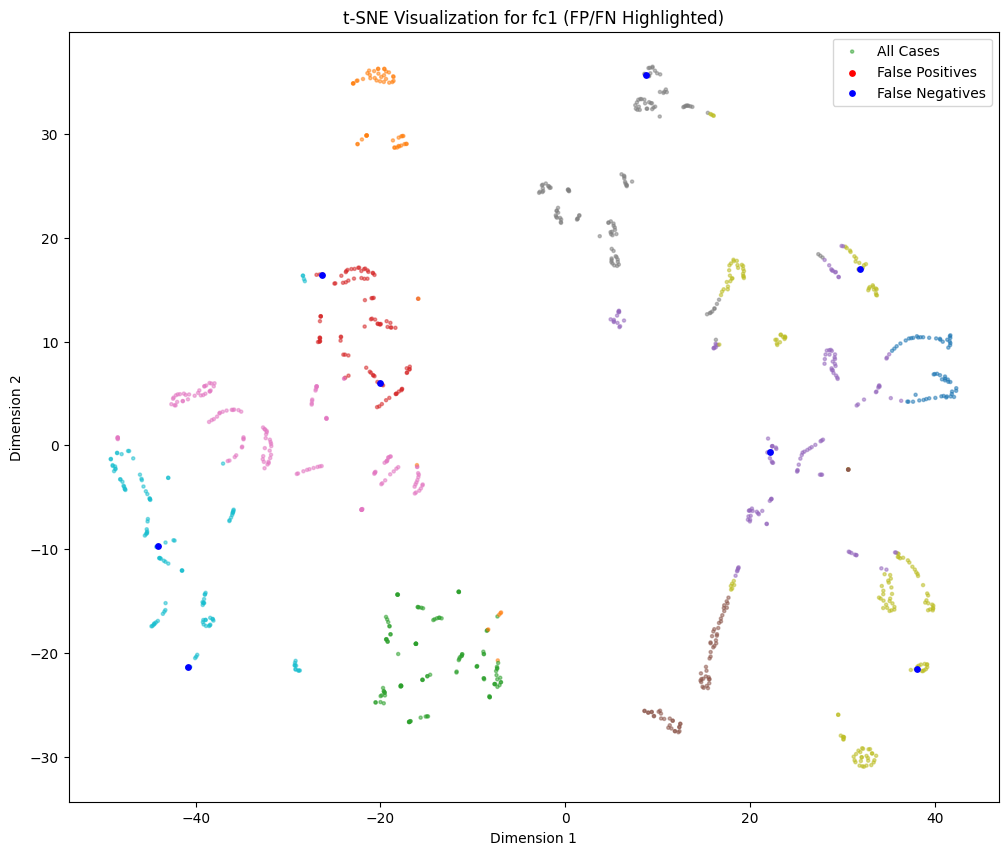